## Graphs Processing

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# task = "LinReg"
task = "BinClass"


## Statistics table generation

In [16]:
path_1 = f"../scripts/results/seeds/{task}_Synth_seeds_20_by_2.csv"
path_2 = f"../scripts/results/seeds/{task}_AU_seeds_14_by_2.csv"
path_3 = f"../scripts/results/seeds/{task}_Splice_seeds_287_by_3.csv"

df_1 = pd.read_csv(path_1)
df_2 = pd.read_csv(path_2)
df_3 = pd.read_csv(path_3)

df_1["dataset"] = ["Synthetic"] * len(df_1["epoch"])
df_2["dataset"] = ["Australian"] * len(df_2["epoch"])
df_3["dataset"] = ["Splice"] * len(df_3["epoch"])

df_bin = pd.concat([df_1, df_2, df_3])

df_bin.head(15)

,Unnamed: 0,epoch,optimizer,lr,loss,accuracy,mode,rank,eps,X_type,avg_epoch_time,epoch_time,batch_size,data_seed,dataset
0,0,0,Shampoo,0.05,0.665284,0.633333,test,NaN,0.1,X true,0.000000,0.000000,1,1,Synthetic
1,1,0,Shampoo,0.05,0.682196,0.516667,train,NaN,0.1,X true,0.000000,0.000000,1,1,Synthetic
2,2,1,Shampoo,0.05,0.539331,0.866667,test,NaN,0.1,X true,3.118994,3.118994,1,1,Synthetic
3,3,1,Shampoo,0.05,0.524214,0.920833,train,NaN,0.1,X true,3.118994,3.118994,1,1,Synthetic
4,4,2,Shampoo,0.05,0.500161,0.866667,test,NaN,0.1,X true,2.990093,5.980186,1,1,Synthetic
5,5,2,Shampoo,0.05,0.477330,0.958333,train,NaN,0.1,X true,2.990093,5.980186,1,1,Synthetic
6,6,3,Shampoo,0.05,0.475584,0.900000,test,NaN,0.1,X true,2.945452,8.836357,1,1,Synthetic
7,7,3,Shampoo,0.05,0.448405,0.958333,train,NaN,0.1,X true,2.945452,8.836357,1,1,Synthetic
8,8,4,Shampoo,0.05,0.457279,0.900000,test,NaN,0.1,X true,2.925790,11.703161,1,1,Synthetic
9,9,4,Shampoo,0.05,0.427547,0.958333,train,NaN,0.1,X true,2.925790,11.703161,1,1,Synthetic


In [17]:
import numpy as np 

grouped_accuracies = df_bin.groupby(['dataset', 'optimizer'])['accuracy'].apply(list)
table_data = grouped_accuracies.unstack()

# --- 3. Identify the Best Optimizer for Each Dataset ---
# Calculate the mean accuracy for each optimizer on each dataset
mean_accuracies = table_data.applymap(np.mean)

# Find the name of the optimizer with the highest mean accuracy for each dataset
best_optimizer_series = mean_accuracies.idxmax(axis=1)

# --- 4. Create the Final Summary Table ---
summary_rows = []
for dataset, best_optimizer_name in best_optimizer_series.items():
    # Retrieve the list of accuracies for the best optimizer
    acc_list = table_data.loc[dataset, best_optimizer_name]
    
    # Calculate mean and standard deviation
    mean_acc = np.mean(acc_list)
    std_acc = np.std(acc_list)
    
    # Format the accuracy string
    formatted_accuracy = f"{mean_acc:.1%} ± {std_acc:.1%}"
    
    # Append the results for the new table
    summary_rows.append({
        "Best Optimizer": best_optimizer_name,
        "Best Accuracy": formatted_accuracy
    })

# Create a new DataFrame from the collected rows
best_accuracy_table = pd.DataFrame(summary_rows, index=table_data.index)


# --- 5. Display the Final Table ---
print("Best Performing Optimizer per Dataset\n")
print(best_accuracy_table.to_string())

Best Performing Optimizer per Dataset

              Best Optimizer  Best Accuracy
dataset                                    
Australian  AdaGramPS rank 1  97.6% ± 10.7%
Splice         Torch_Adagrad  95.0% ± 10.4%
Synthetic      Torch_Adagrad   91.9% ± 8.9%


/tmp/ipykernel_1525097/2548373781.py:8: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



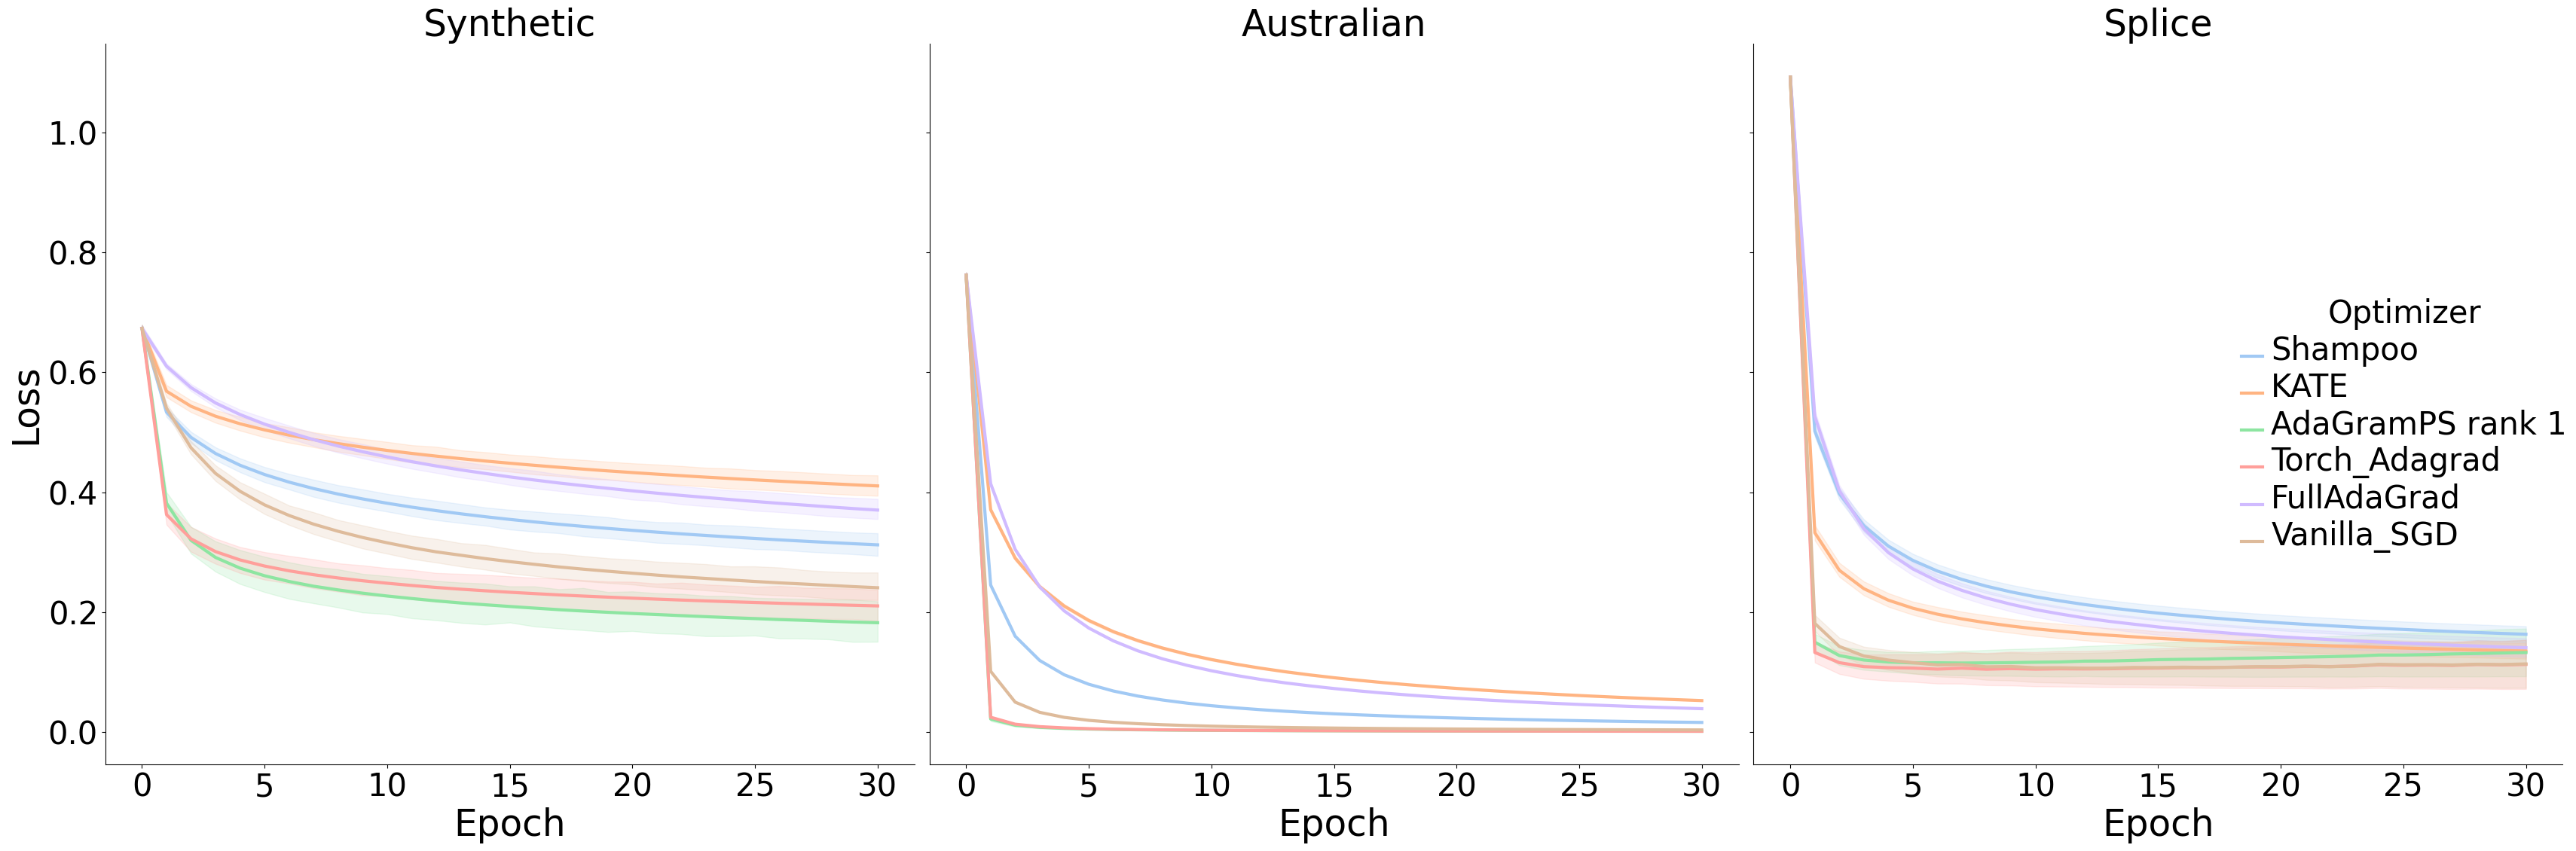

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Draw the grid as usual
dir= "./plots"

g = sns.FacetGrid(
    df_bin,
    col='dataset',
    hue='optimizer',
    palette='pastel',
    margin_titles=True,
    height=12,  # Increased from 5 to 8 to make each facet taller
    aspect=0.9
    
)

# 2. Map the lineplot to the grid
g.map(sns.lineplot, 'epoch', 'loss', linewidth=3)

# 3. Set the font sizes for all text elements
# Set facet titles and axis labels to fontsize 24
g.set_titles(col_template="{col_name}", size=35)
g.set_axis_labels("Epoch", "Loss", fontsize=35)

# Set the tick label font size to 20 for all axes
g.tick_params(axis='both', which='major', labelsize=30)

# 4. Add and format the legend
# Set legend title to 24 and legend item labels to 20
g.add_legend(title='Optimizer')

# 2. Now, access the legend's title object and set its font size.
g.legend.get_title().set_fontsize(30)

# 2. To set the font size of the legend labels, you iterate through them
for text in g.legend.get_texts():
    text.set_fontsize(30)

# 5. Adjust layout and add an overall title
g.fig.subplots_adjust(top=0.8) # Make room for the main title
# Display the plot
output_path = os.path.join(dir, 'Losses_classification.pdf')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()



## Hyperparams

In [26]:
path = f"../scripts/results/Iso_grid_search.csv"

df_bin = pd.read_csv(path)
df_bin.head(15)

,optimizer,lr,rank,eps,batch_size,data_seed,epoch_time,avg_epoch_time,epoch,loss,accuracy,mode
0,FullAdaGrad,0.1,NaN,0.5,1,10,0.000000,0.000000,0,0.888742,0.400000,test
1,FullAdaGrad,0.1,NaN,0.5,1,10,0.000000,0.000000,0,0.847151,0.420833,train
2,FullAdaGrad,0.1,NaN,0.5,1,10,0.954294,0.954294,1,0.749626,0.500000,test
3,FullAdaGrad,0.1,NaN,0.5,1,10,0.954294,0.954294,1,0.701360,0.550000,train
4,FullAdaGrad,0.1,NaN,0.5,1,10,1.580026,0.790013,2,0.716678,0.533333,test
5,FullAdaGrad,0.1,NaN,0.5,1,10,1.580026,0.790013,2,0.673708,0.583333,train
6,FullAdaGrad,0.1,NaN,0.5,1,10,2.234637,0.744879,3,0.698637,0.566667,test
7,FullAdaGrad,0.1,NaN,0.5,1,10,2.234637,0.744879,3,0.657981,0.600000,train
8,FullAdaGrad,0.1,NaN,0.5,1,10,2.788290,0.697073,4,0.685647,0.600000,test
9,FullAdaGrad,0.1,NaN,0.5,1,10,2.788290,0.697073,4,0.646850,0.616667,train


In [5]:
!pip install --upgrade nbformat

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [nbformat]6/7 [nbformat]a]]


In [27]:

import pandas as pd
import plotly.express as px

df_grid_search = df_bin

df = df_grid_search[(df_grid_search['mode'] == 'test') & (df_grid_search['optimizer'].str.contains("AdaGram"))]

hyperparameter_dims = ['lr', 'batch_size',"eps", "rank",'accuracy']
hyperparameter_cols = ['lr', 'batch_size', "eps", "rank",]
performance_metric = 'accuracy'
time_col = 'epoch_time'

df_sorted = df.sort_values(
    by=[performance_metric, time_col], 
    ascending=[False, True]
)

df_earliest_best = df_sorted.drop_duplicates(
    subset=hyperparameter_cols, 
    keep='first'
)

fig = px.parallel_coordinates(
    df_earliest_best,
    dimensions=hyperparameter_dims,
    color=performance_metric,
    color_continuous_scale=px.colors.diverging.RdBu_r,
    labels={
        "lr": "Learning Rate",
        "batch_size": "Batch Size",
        "eps": "Epsilon",
        "rank": "Rank",
        "accuracy": "accuracy"
    },
    title="Hyperparameter Optimization Analysis"
)

fig.update_layout(
    height=800  # Set the desired height of the plot in pixels
)
fig.show()
 


In [22]:
file_to_update = "../scripts/configs/classification/config_Synth_Iso.yaml"

In [7]:
!pip install ruamel

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
ERROR: Could not find a version that satisfies the requirement ruamel (from versions: none)
ERROR: No matching distribution found for ruamel


In [23]:
import pandas as pd
import numpy as np
from ruamel.yaml import YAML
import os


def find_and_update_best_params(df_grid_search, config_path):
    """
    Finds the best hyperparameters for each optimizer based on the earliest
    minimum loss and updates a YAML configuration file with these parameters,
    using block-style formatting for lists.

    Args:
        df_grid_search (pd.DataFrame): DataFrame containing experiment results.
        config_path (str): The file path to the YAML configuration file.
    """
    # 1. Filter for test results and extract base optimizer name
    df_test = df_grid_search[df_grid_search['mode'] == 'test'].copy()
    df_test['base_optimizer'] = df_test['optimizer'].apply(lambda x: x.split(' ')[0])

    # 2. Sort by loss (ascending) and then by epoch (ascending)
    df_sorted = df_test.sort_values(by=['accuracy', 'epoch'], ascending=[False, True])

    # 3. Get the single best parameter set for each base optimizer
    df_best_per_optimizer = df_sorted.drop_duplicates(subset=['base_optimizer'], keep='first')
    
    print("--- Best performing parameters found for each optimizer ---")
    print(df_best_per_optimizer[['base_optimizer', 'optimizer', 'accuracy', 'epoch', 'lr', 'batch_size', 'eps', 'rank']])
    print("-" * 60)

    # 4. Load the YAML configuration file and set the desired style
    yaml = YAML()
    yaml.preserve_quotes = True
    yaml.default_flow_style = True

    try:
        with open(config_path, 'r') as f:
            config = yaml.load(f)
    except FileNotFoundError:
        print(f"Error: Configuration file not found at {config_path}")
        return

    # 5. Iterate through the best results and update the config
    for _, row in df_best_per_optimizer.iterrows():
        opt_name = row['base_optimizer'] 
        
        if opt_name in config['optimizers']:
            print(f"Updating configuration for: {opt_name}")
            
            config['optimizers'][opt_name]['learning_rates'] = [row['lr']]
            config['optimizers'][opt_name]['batch_size'] = [row['batch_size']]
            
            if pd.notna(row['eps']) and str(row['eps']).lower() != 'nan':
                config['optimizers'][opt_name]['eps'] = [row['eps']]
            else:
                config['optimizers'][opt_name]['eps'] = ['nan']

            if config['optimizers'][opt_name].get('requires_rank') and pd.notna(row['rank']):
                config['optimizers'][opt_name]['ranks'] = [int(row['rank'])]
        else:
            print(f"Warning: Optimizer '{opt_name}' from results not found in config. Skipping.")

    # 6. Write the updated configuration back to the file
    try:
        with open(config_path, 'w') as f:
            yaml.dump(config, f)
        print(f"\nConfiguration file '{config_path}' has been successfully updated.")
    except Exception as e: 
        print(f"Error writing to configuration file: {e}")

find_and_update_best_params(df_grid_search, file_to_update)


--- Best performing parameters found for each optimizer ---
     base_optimizer         optimizer  accuracy  epoch   lr  batch_size   eps  \
8080    Vanilla_SGD       Vanilla_SGD  1.000000      8  0.1           1   NaN   
1532           KATE              KATE  1.000000     10  0.1          32  0.50   
7580  Torch_Adagrad     Torch_Adagrad  1.000000     10  0.1          32  0.50   
4574      AdaGramPS  AdaGramPS rank 1  1.000000     19  0.1          32  0.50   
160     FullAdaGrad       FullAdaGrad  0.483333     17  0.1           1  0.01   

      rank  
8080   NaN  
1532   NaN  
7580   NaN  
4574   1.0  
160    NaN  
------------------------------------------------------------
Updating configuration for: Vanilla_SGD
Updating configuration for: KATE
Updating configuration for: Torch_Adagrad
Updating configuration for: AdaGramPS
Updating configuration for: FullAdaGrad

Configuration file '../scripts/configs/classification/config_Synth_Iso.yaml' has been successfully updated.


## Plots

In [24]:
path = f"../scripts/results/Iso_seeds.csv"

df_bin = pd.read_csv(path)
df_bin.head(15)

,optimizer,lr,rank,eps,batch_size,data_seed,epoch_time,avg_epoch_time,epoch,loss,accuracy,mode
0,FullAdaGrad,0.1,NaN,0.5,32,1,0.000000,0.000000,0,0.788719,0.366667,test
1,FullAdaGrad,0.1,NaN,0.5,32,1,0.000000,0.000000,0,0.709740,0.529167,train
2,FullAdaGrad,0.1,NaN,0.5,32,1,0.365819,0.365819,1,0.724098,0.533333,test
3,FullAdaGrad,0.1,NaN,0.5,32,1,0.365819,0.365819,1,0.592269,0.675000,train
4,FullAdaGrad,0.1,NaN,0.5,32,1,0.386779,0.193389,2,0.698020,0.566667,test
5,FullAdaGrad,0.1,NaN,0.5,32,1,0.386779,0.193389,2,0.553094,0.716667,train
6,FullAdaGrad,0.1,NaN,0.5,32,1,0.408401,0.136134,3,0.679618,0.616667,test
7,FullAdaGrad,0.1,NaN,0.5,32,1,0.408401,0.136134,3,0.528435,0.737500,train
8,FullAdaGrad,0.1,NaN,0.5,32,1,0.429841,0.107460,4,0.673219,0.633333,test
9,FullAdaGrad,0.1,NaN,0.5,32,1,0.429841,0.107460,4,0.510578,0.745833,train


/tmp/ipykernel_845760/553869393.py:12: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_845760/553869393.py:16: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



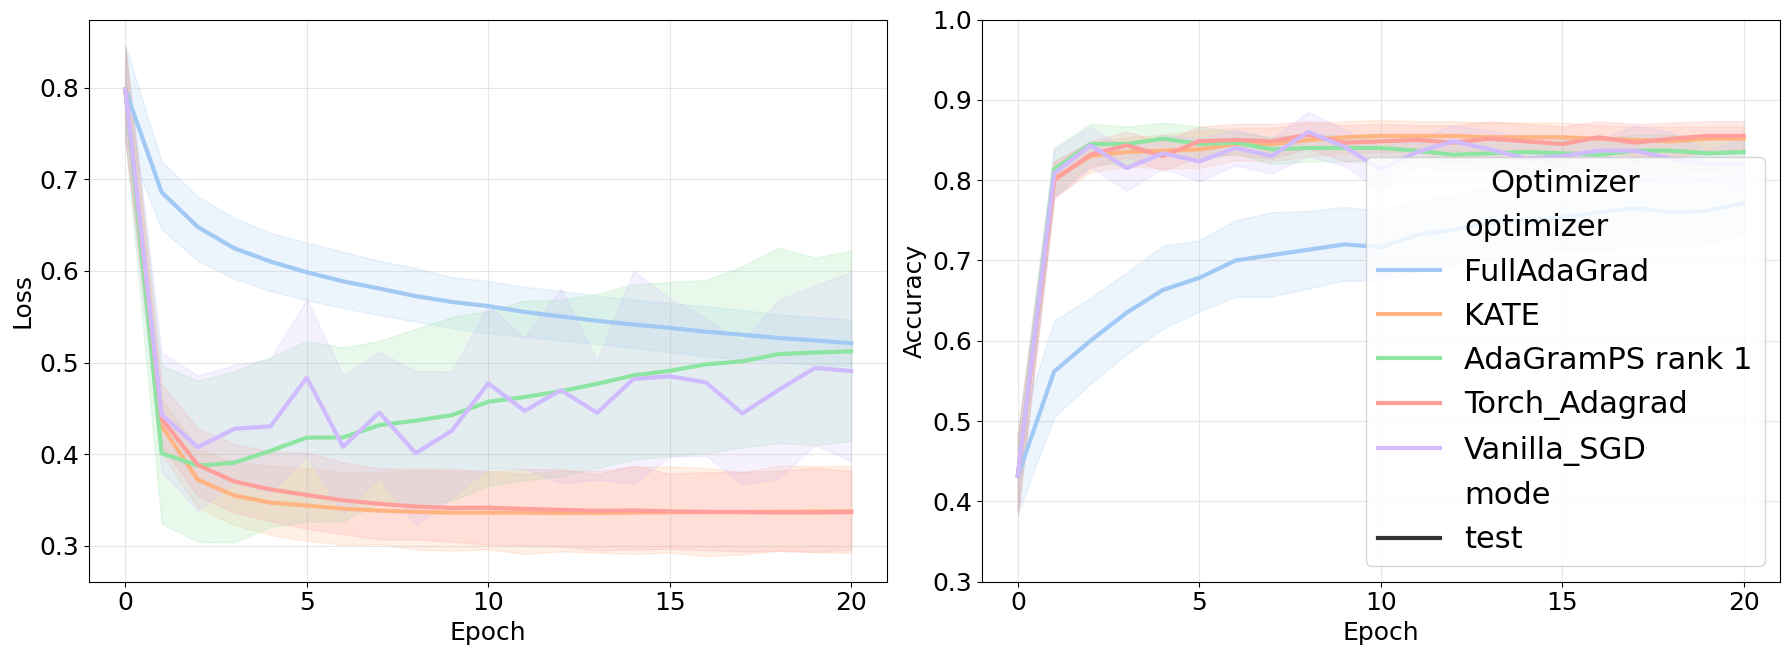

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
import os
import numpy as np

dir = './plots'
plot_name = 'Corr_Aniso_bin_classification.pdf'

df_test = df_bin.query("mode == 'test' and optimizer != 'AdaGramPS rank 2' and optimizer != 'AdaGramPS rank 3' and optimizer != 'AdaGramPS rank 4' and optimizer != 'AdaGramPS rank 5'")
best_accuracies = df_test.groupby('optimizer').apply(
    lambda g: g.loc[g['accuracy'].idxmax()]
).reset_index(drop=True)

best_losses = df_test.groupby('optimizer').apply(
    lambda g: g.loc[g['loss'].idxmin()]
).reset_index(drop=True)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# Color mapping
optimizers = df_test['optimizer'].unique()
palette = sns.color_palette('pastel', len(optimizers))
color_map = {opt: color for opt, color in zip(optimizers, palette)}

# Plot loss over epochs (left subplot)
sns.lineplot(data=df_test, x='epoch', y='loss', hue='optimizer', linewidth=3,style='mode',
              legend=False, palette=color_map, ax=axes[0])


# axes[0].set_title('Loss over Epochs', fontsize=22)
axes[0].set_xlabel('Epoch', fontsize=18)
axes[0].set_ylabel('Loss', fontsize=18)
# axes[0].set_yscale('log')  # Keep log scale for loss
axes[0].grid(True, alpha=0.3)

# for ax in grid.axes.flat:
    # --- Add this line to set the x-axis limit ---

# Plot accuracy over epochs (right subplot)
sns.lineplot(data=df_test, x='epoch', y='accuracy', hue='optimizer', linewidth=3, style='mode',
              palette=color_map, ax=axes[1])

# Add scatter points
# sns.scatterplot(data=best_accuracies.query("optimizer != 'Torch_Adagrad'"), x='epoch', y='accuracy', hue='optimizer', 
#                 s=50, edgecolor='black', linewidth=1.5, legend=False, zorder=5, palette=color_map, ax=axes[1])

# # Add star marker for Torch_Adagrad
# torch_adagrad_best_row = best_accuracies[best_accuracies['optimizer'] == 'Torch_Adagrad']
# if not torch_adagrad_best_row.empty:
#     torch_adagrad_best = torch_adagrad_best_row.iloc[0]
#     axes[1].scatter(torch_adagrad_best['epoch'], torch_adagrad_best['accuracy'], 
#                    s=200, marker='*', c=color_map['Torch_Adagrad'], edgecolors='black', linewidths=1.5, 
#                    zorder=10)

# axes[1].set_title('Accuracy over Epochs', fontsize=22)
axes[1].set_xlabel('Epoch', fontsize=18)
axes[1].set_ylabel('Accuracy', fontsize=18)


# FIX 1: Remove log scale from accuracy plot
# axes[1].set_yscale('log')  # Comment this out or remove it

# FIX 2: Set better y-axis limits for accuracy
axes[1].set_ylim(0.5, 1.0)  # Adjust range to show meaningful differences

# FIX 3: Improve tick formatting
for ax in axes:
    ax.tick_params(axis='x', which='major', labelsize=18)
    ax.tick_params(axis='y', which='major', labelsize=18)
    
# FIX 4: Set specific tick locations for better readability
# axes[0].set_xticks(range(0, 21, 5))  # Ticks every 5 epochs
axes[1].set_xticks(range(0, 21, 5))
axes[1].set_yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])  # Clear accuracy intervals

handles, labels = axes[1].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
axes[1].legend(unique_labels.values(), unique_labels.keys(),
               fontsize=22, loc='lower right', title='Optimizer', title_fontsize='22')

# Legend with better positioning
# handles, labels = axes[1].get_legend_handles_labels()
# star_handle = Line2D([0], [0], marker='*', color=color_map['Torch_Adagrad'], label='Torch_Adagrad',
#                       markeredgecolor='black', markersize=15, linewidth=1)
# handles.append(star_handle)
# labels.append('Torch_Adagrad')

# FIX 5: Better legend positioning
# axes[1].legend(handles=handles, labels=labels, fontsize=14, 
#                loc='lower right', framealpha=0.9)  # Adjust location as needed

axes[1].grid(True, alpha=0.3)
output_path = os.path.join(dir, plot_name)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()



In [10]:
import matplotlib.ticker as mticker

dir = './plots'
os.makedirs(dir, exist_ok=True)

path = f"../scripts/results/time/BinClass_Splice_time_budget287_by_3.csv"
df_bin = pd.read_csv(path)

df_test = df_bin[df_bin['mode'] == 'test']
df_test.loc[(df_test['optimizer'] == 'Shampoo') & (df_test['epoch'] == 2), 'time'] = 60
best_accuracies = df_test.loc[df_test.groupby('optimizer')['accuracy'].idxmax()].reset_index(drop=True)
time_budget = 60

# --- Plotting Setup ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=False)

# Define optimizers and create maps for colors, markers, and sizes
optimizers = df_test['optimizer'].unique()
palette = sns.color_palette('pastel', len(optimizers))
color_map = {opt: color for opt, color in zip(optimizers, palette)}
marker_map = {opt: 'o' for opt in optimizers}
marker_map['Torch_Adagrad'] = '*'
sizes_map = {opt: 80 for opt in optimizers}
sizes_map['Torch_Adagrad'] = 400

# --- Left Subplot: Loss vs. Time ---
sns.lineplot(data=df_test, x='time', y='loss', hue='optimizer', linewidth=3,
             markers=True, legend=False, palette=color_map, ax=axes[0])
axes[0].set_xlabel('Time (s)', fontsize=24)
axes[0].set_ylabel('Loss', fontsize=24)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

# --- Right Subplot: Accuracy vs. Time ---
sns.lineplot(data=df_test, x='time', y='accuracy', hue='optimizer', linewidth=3,
             markers=True, palette=color_map, ax=axes[1])
sns.scatterplot(data=best_accuracies, x='time', y='accuracy', hue='optimizer',
                s=[sizes_map[opt] for opt in best_accuracies['optimizer']],
                edgecolor='black', linewidth=1.5, legend=False,
                zorder=5, palette=color_map, ax=axes[1], style='optimizer',
                markers=marker_map)
axes[1].set_xlabel('Time (s)', fontsize=24)
axes[1].set_ylabel('Accuracy', fontsize=24)
axes[1].set_ylim(0.4, 1.05)
axes[1].set_yticks(np.arange(0.4, 1.05, 0.1))
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# --- KEY CHANGES: X-axis Ticks and Formatting ---
formatter = mticker.FormatStrFormatter('%.2f')
for ax in axes:
    ax.set_xlim(0, time_budget + 0.5)
    # Set x-ticks to have a unit space value (every 1 second)
    ax.set_xticks(np.arange(0, time_budget + 0.5, 10))
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis='both', which='major', labelsize=16)

# --- Legend Handling ---
handles, labels = axes[1].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
axes[1].legend(unique_labels.values(), unique_labels.keys(),
               fontsize=22, loc='lower right', title='Optimizer', title_fontsize='22')

# --- Final Save and Show ---
output_path = os.path.join(dir, 'Splice_bin_classification_fixed_time.pdf')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(output_path, dpi=300)

FileNotFoundError: [Errno 2] No such file or directory: '../scripts/results/time/BinClass_Splice_time_budget287_by_3.csv'

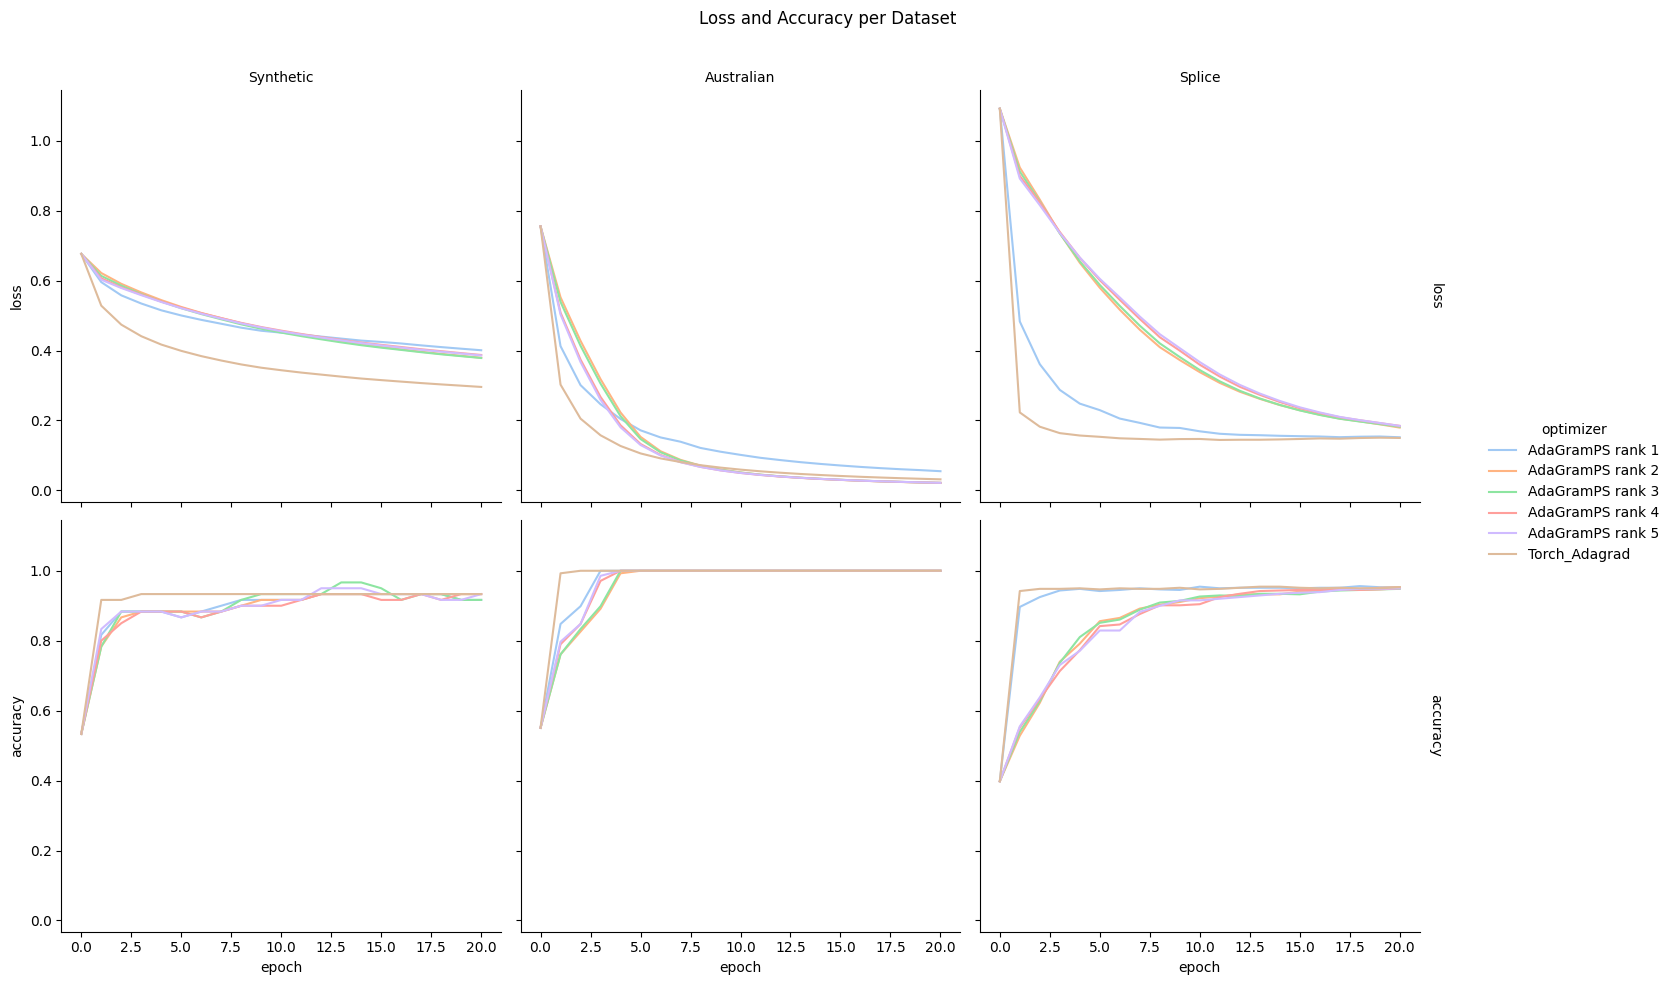

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df_long.query('mode == "test" and batch_size == 32'),
    row='metric', col='dataset',
    hue='optimizer', palette='pastel',
    margin_titles=True, height=5
)
g.map(sns.lineplot, 'epoch', 'value')
g.set_axis_labels('epoch', '')
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Loss and Accuracy per Dataset')

for ax, metric in zip(g.axes[:,0], ['loss', 'accuracy']):
    ax.set_ylabel(metric)

g.add_legend()  # <-- Add this to show the hue variable legend

plt.show()


## Matrix G evolution

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import re

# Directory containing G matrix files
matrix_dir = "../scripts/matrix_G/"
matrix_out_dir = "../scripts/matrix_G_pngs/"

def numerical_key(filename):
    # Extract numbers as integers; returns (inf,) if no number is found
    numbers = re.findall(r'\d+', os.path.basename(filename))
    return tuple(map(int, numbers)) if numbers else (float('inf'),)

# Find all .pt files in the directory
file_pattern = os.path.join(matrix_dir, "*.pt")
files = glob.glob(file_pattern)
files.sort(key=numerical_key)  # Sort for chronological order

print(f"Found {len(files)} G matrix files to process...")

# Process each file
for filename in files[:100]:
    try:
        # Extract just the filename without path for display
        base_filename = os.path.basename(filename)
        print(f"Processing: {base_filename}")
        
        # Load G matrix
        G_matrix = torch.load(filename, map_location='cpu')
        
        # Convert to numpy array for plotting
        G_numpy = G_matrix.numpy()
        
        # Create heatmap
        plt.figure(figsize=(10, 8))
        plt.imshow(G_numpy, cmap='viridis', aspect='auto')
        plt.colorbar(label='Values')
        
        # Extract epoch info from filename for better title
        if 'epoch_' and 'batch_' in base_filename:
            epoch_info = base_filename.split('epoch_')[1].split('_')[0]
            batch_info = base_filename.split('batch_')[1].split('_')[0]

            title = f'Heatmap of G Matrix - Epoch {epoch_info}, step {batch_info}'
        else:
            title = f'Heatmap of G Matrix - {base_filename}'
        
        plt.title(title)
        plt.xlabel('Columns')
        plt.ylabel('Rows')
        
        # Create output filename (replace .pt with .png)
        output_filename = base_filename.replace('.pt', '.png')
        output_path = os.path.join(matrix_out_dir, output_filename)
        
        # Save the plot as PNG
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()  # Close the figure to free memory
        
        print(f"Saved: {output_filename}")
        
    except Exception as e:
        print(f"Error processing {base_filename}: {str(e)}")
        continue

print("Processing complete!")


Found 401 G matrix files to process...
Processing: G_matrix_epoch_0_adagram_task_BinClass.pt
Saved: G_matrix_epoch_0_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_0_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_0_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_1_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_1_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_2_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_2_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_3_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_3_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_4_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_4_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_5_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_5_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_6_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_6_adagram_task_BinClass.png
Processing: G_mat

In [3]:
from PIL import Image
import glob
import os


def create_gif_from_pngs(pattern="*.png", output="output.gif", directory=".", duration=500, optimize=True):
    """Create GIF from PNG files matching the pattern in a specific directory"""
    
    # Construct full pattern with directory path
    full_pattern = os.path.join(directory, pattern)
    files = glob.glob(full_pattern)
    print(f"Looking in: {full_pattern}")
    print(f"Found files: {files}")
    

    files.sort(key=numerical_key)
    
    if not files:
        print(f"No files found matching pattern: {full_pattern}")
        return
    
    # Load images
    images = [Image.open(f) for f in files]
    
    # Create output path in the same directory
    output_path = os.path.join(directory, output)
    
    # Create GIF
    images[0].save(
        output_path,
        save_all=True,
        append_images=images[1:],
        duration=duration,
        loop=0,
        optimize=optimize
    )
    
    print(f"GIF created: {output_path}")
    print(f"Frames: {len(images)}")

# Usage for your specific case
matrix_dir = "../scripts/matrix_G_pngs/"
create_gif_from_pngs("G_matrix_epoch_*.png", "matrix_evolution.gif", matrix_dir, duration=800)
create_gif_from_pngs("*.png", "all_matrices.gif", matrix_dir)


Looking in: ../scripts/matrix_G_pngs/G_matrix_epoch_*.png
Found files: ['../scripts/matrix_G_pngs\\G_matrix_epoch_0_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_0_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_10_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_11_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_12_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_13_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_14_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_15_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_16_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_17_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_18_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_bat